In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import shapefile as shp

import sys
sys.path.append("../code")
import households as hh

In [2]:
# matplotlib settings
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["axes.titlesize"]= 10
mpl.rcParams["legend.fontsize"] = 8
mpl.rcParams["legend.title_fontsize"] = 10
cm = 1/2.54

In [3]:
# load European borders from shapefile
sf = shp.Reader('../data/eumap_shapefiles/CNTR_RG_60M_2020_4326.shp/CNTR_RG_60M_2020_4326.shp')
sf_inland = shp.Reader('../data/eumap_shapefiles/CNTR_BN_60M_2020_4326_INLAND.shp/CNTR_BN_60M_2020_4326_INLAND.shp')
ctr = pd.DataFrame([list(i) for i in sf.records()])

In [4]:
# load list of countries in our analysis
countries = hh.read_data('../results/prevalence_vectors/Prevalence2021W22(gamma=0.85).csv').columns.sort_values()
countries = countries.drop('Europe**', errors='ignore')
N = len(countries)

In [5]:
# calculating effective household size for countries identified by ISO2
idx = [0]*N
mratio = [0]*N
for i in range(N):
    iso2 = hh.get_iso2(countries[i])
    if iso2=='GR': iso2='EL'
    mratio[i] = hh.momentratio(hh.get_distribution(iso2))
    idx[i] = ctr[ctr[4]==iso2].index[0]

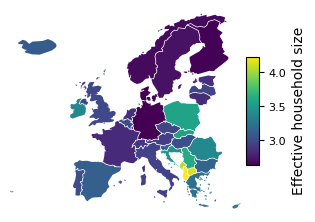

In [6]:
# plotting
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(mratio), vmax=max(mratio))

fig = plt.figure(figsize=[8*cm,5.5*cm])
ax = fig.add_axes([0.0,0.0,0.75,1])
ax.set_aspect(aspect=1.4)

for c in range(N):
    
    shape = sf.shape(idx[c])
    data = np.array(shape.points).transpose()
    parts = shape.parts
    parts.append(len(shape.points))
    
    for i in range(len(parts)-1):
        ax.fill(data[0,parts[i]:parts[i+1]], data[1,parts[i]:parts[i+1]],
                color = cmap(norm(mratio[c])), lw=0)

    # plotting largest component for each country
#    m = np.diff(parts).argmax()
#    ax.plot(data[0,parts[m]:parts[m+1]], data[1,parts[m]:parts[m+1]], color = 'black', lw=.5)
#    ax.fill(data[0,parts[m]:parts[m+1]], data[1,parts[m]:parts[m+1]], color = colors[c+1])



# inland borders in white
for shape in sf_inland.shapes():
    data = np.array(shape.points).transpose()
    ax.plot(data[0], data[1], color='white', lw=0.5)
    
ax.axis('off')
ax.set_xlim(-26,36)
ax.set_ylim(34,72)

cax = fig.add_axes([0.75, 0.25, 0.04, 0.5])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm)
cb.set_label(r'Effective household size')


fig.savefig("../figures/figure_1b.pdf")